# Clasificación y segmentación de lesiones cutáneas: comparación de modelos preentrenados

Este cuaderno desarrolla un prototipo académico que clasifica imágenes del conjunto utilizado en dos etiquetas, **Benign** y **Malignant**. Se parte del análisis exploratorio y del primer entrenamiento de EfficientNet-B0 realizados por el equipo. Sobre esa base se comparan EfficientNet-B0 y ResNet-18 bajo la misma división de datos, se seleccionan modelo y umbral exclusivamente con validación y se informa el resultado final en el conjunto de prueba.

El recorrido es: obtener y examinar imágenes, fijar las divisiones, revisar duplicados, preparar entradas, entrenar dos arquitecturas preentrenadas, elegir una con validación, evaluar y ejecutar una inferencia sobre una imagen compatible. El cuaderno exporta las tablas y el modelo necesarios para documentar el experimento en el repositorio.

Las etiquetas se toman de los nombres de las carpetas. La procedencia clínica y los diagnósticos específicos incluidos en cada clase requieren verificación con la fuente original. La salida del prototipo no constituye un diagnóstico médico.

## 1. Entorno y datos

Se registra el entorno efectivo de ejecución para que los resultados puedan reproducirse. La versión exacta, la fuente primaria y la licencia del conjunto se consignan como verificadas solo cuando la ficha del proveedor las documente de forma inequívoca.

In [1]:
!pip -q install kagglehub

In [2]:
import hashlib
import importlib.metadata as md
import json
import os
import platform
import random
import re
import sys
import time
from collections import defaultdict
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
from PIL import Image
import sklearn
import torch
import torchvision
from sklearn.metrics import (confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import (EfficientNet_B0_Weights, ResNet18_Weights,
                                efficientnet_b0, resnet18)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASET_HANDLE = 'ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant'
DATASET_URL = 'https://www.kaggle.com/datasets/' + DATASET_HANDLE
LABEL2IDX = {'Benign': 0, 'Malignant': 1}
IMG_SIZE = 224
print('Dispositivo:', DEVICE)

Dispositivo: cuda


In [3]:
root = Path(kagglehub.dataset_download(DATASET_HANDLE))
print('Dataset:', DATASET_URL)
print('Ruta local:', root)
version_match = re.search(r'/versions/(\d+)(?:/|$)', str(root).replace('\\', '/'))
dataset_version = version_match.group(1) if version_match else None
print('Versión identificable en ruta:', dataset_version or 'no visible: verificar en Kaggle')

rows = []
for part in ('train', 'test'):
    for label in LABEL2IDX:
        folder = root / part / label
        if not folder.is_dir():
            raise FileNotFoundError(f'No se encontró la carpeta esperada: {folder}')
        for path in sorted(folder.iterdir()):
            if not path.is_file():
                continue
            try:
                with Image.open(path) as image:
                    width, height, mode = *image.size, image.mode
                    image.verify()
            except Exception as error:
                raise ValueError(f'Imagen ilegible: {path}') from error
            rows.append({'path': str(path), 'relative_path': path.relative_to(root).as_posix(),
                         'part': part, 'label': label, 'width': width,
                         'height': height, 'mode': mode})

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError('No se encontraron imágenes')
print('Imágenes encontradas:', len(df))
display(pd.crosstab(df['part'], df['label']))

100%|██████████| 79.4M/79.4M [00:04<00:00, 19.4MB/s]

Extracting files...


Dataset: https://www.kaggle.com/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant
Ruta local: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1
Versión identificable en ruta: 1
Imágenes encontradas: 13879


label,Benign,Malignant
part,,
test,1000,1000
train,6289,5590


## 2. División reproducible y exploración del entrenamiento

Se conserva la partición de prueba proporcionada por el conjunto. La carpeta de entrenamiento se divide de forma estratificada en entrenamiento y validación; la asignación y la semilla se guardan en `split_manifest.csv`. Las decisiones de preparación se basan solo en imágenes asignadas a entrenamiento.

In [4]:
original_train = df[df.part == 'train']
idx_train, idx_val = train_test_split(
    original_train.index.to_numpy(), test_size=0.15,
    stratify=original_train['label'], random_state=SEED,
)
df['subset'] = 'test'
df.loc[idx_train, 'subset'] = 'train'
df.loc[idx_val, 'subset'] = 'val'
assert set(df.subset) == {'train', 'val', 'test'}
assert df[['relative_path', 'subset']].drop_duplicates().shape[0] == len(df)
manifest = df[['relative_path', 'part', 'label', 'subset']].sort_values('relative_path')
manifest.to_csv(OUT / 'split_manifest.csv', index=False)
manifest_sha256 = hashlib.sha256((OUT / 'split_manifest.csv').read_bytes()).hexdigest()
display(pd.crosstab(df['subset'], df['label']))
print('SHA256 del manifiesto:', manifest_sha256)

label,Benign,Malignant
subset,,
test,1000,1000
train,5346,4751
val,943,839


SHA256 del manifiesto: b59736fb5ab24432c55f30445a8832ae4f66ea4fd5098c20759c62d9302b8731


Dimensiones en entrenamiento:


,width,height,mode,images
0,224,224,RGB,10097


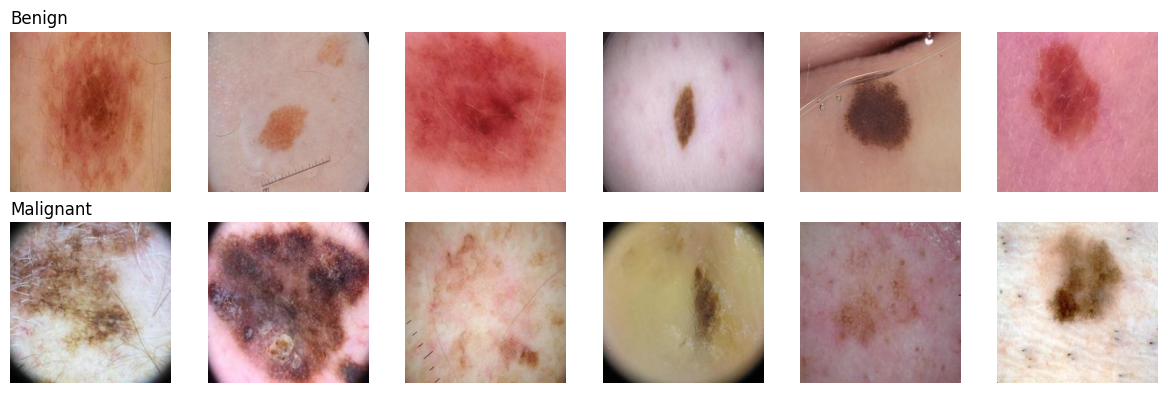

Contraste:   0%|          | 0/10097 [00:00<?, ?it/s]

Imágenes de entrenamiento señaladas para revisión: 87


,relative_path,mean,std
1970,train/Benign/306.jpg,183.022644,5.785622
10052,train/Malignant/953.jpg,135.836655,6.078602
5372,train/Malignant/1026.jpg,107.891182,6.611364
10093,train/Malignant/996.jpg,133.114761,6.791605
5585,train/Malignant/1262.jpg,141.338928,6.931430
5373,train/Malignant/1027.jpg,128.472443,7.228405
1999,train/Benign/3089.jpg,136.269485,7.255713
6943,train/Malignant/269.jpg,135.961792,7.406219
2546,train/Benign/3673.jpg,136.153107,7.523737
1691,train/Benign/2763.jpg,159.632095,7.675415


In [5]:
train_info = df[df.subset == 'train'].copy()
print('Dimensiones en entrenamiento:')
display(train_info.groupby(['width', 'height', 'mode']).size().reset_index(name='images'))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for row_num, label in enumerate(LABEL2IDX):
    examples = train_info[train_info.label == label].sample(
        n=min(6, (train_info.label == label).sum()), random_state=SEED
    )
    for ax, (_, item) in zip(axes[row_num], examples.iterrows()):
        with Image.open(item.path) as image:
            ax.imshow(image.convert('RGB'))
        ax.axis('off')
    axes[row_num, 0].set_title(label, loc='left')
plt.tight_layout(); plt.show()

# La búsqueda de contrastes poco usuales es descriptiva: no elimina casos sin revisión.
contrast_rows = []
for item in tqdm(train_info.itertuples(index=False), total=len(train_info), desc='Contraste'):
    with Image.open(item.path) as image:
        gray = np.asarray(image.convert('L'), dtype=np.float32)
    contrast_rows.append({'relative_path': item.relative_path, 'mean': float(gray.mean()),
                          'std': float(gray.std())})
contrast = pd.DataFrame(contrast_rows)
suspicious = contrast[(contrast['std'] < 10) | (contrast['mean'] < 25) | (contrast['mean'] > 230)]
print('Imágenes de entrenamiento señaladas para revisión:', len(suspicious))
display(suspicious.sort_values('std').head(12))

## 3. Integridad y similitud de imágenes

El resumen por tamaño y color permitió caracterizar el conjunto. Se complementa con una búsqueda de archivos idénticos y una búsqueda de **candidatos** visualmente similares entre particiones. La distancia visual no acredita que dos fotografías correspondan a la misma lesión o al mismo paciente; las coincidencias se exportan para revisión humana. Si existen identificadores de paciente o lesión, se debe comprobar la independencia de las particiones con esos identificadores.

In [6]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(1 << 20), b''):
            digest.update(block)
    return digest.hexdigest()

def dhash64(path):
    with Image.open(path) as image:
        pixels = np.asarray(image.convert('L').resize((9, 8), Image.Resampling.LANCZOS))
    bits = (pixels[:, 1:] > pixels[:, :-1]).ravel()
    result = 0
    for bit in bits:
        result = (result << 1) | int(bit)
    return result

audit = df[['path', 'relative_path', 'subset', 'label']].reset_index(drop=True).copy()
audit['sha256'] = [sha256_file(p) for p in tqdm(audit.path, desc='SHA256')]
audit['dhash'] = [dhash64(p) for p in tqdm(audit.path, desc='dHash')]
exact_groups = audit.groupby('sha256').filter(lambda group: group.subset.nunique() > 1)
exact_count = exact_groups.sha256.nunique()
print('Grupos de archivos idénticos entre particiones:', exact_count)
exact_groups[['relative_path', 'subset', 'label', 'sha256']].to_csv(
    OUT / 'duplicados_exactos_entre_conjuntos.csv', index=False)

THRESHOLD_HAMMING = 2

bands = [(i * 9, (i + 1) * 9) for i in range(7)]
buckets = defaultdict(list)
close_pairs = []
for idx, item in audit.iterrows():
    value = int(item.dhash)
    possible = set()
    for band_number, (start, end) in enumerate(bands):
        key = (band_number, (value >> start) & ((1 << (end - start)) - 1))
        possible.update(buckets[key])
        buckets[key].append(idx)
    for other in possible:
        prev = audit.iloc[other]
        if prev.subset == item.subset:
            continue
        distance = (int(prev.dhash) ^ value).bit_count()
        if distance <= THRESHOLD_HAMMING:
            close_pairs.append({'path_a': prev.relative_path, 'subset_a': prev.subset,
                                'label_a': prev.label, 'path_b': item.relative_path,
                                'subset_b': item.subset, 'label_b': item.label,
                                'hamming_distance': distance, 'revision': 'pendiente'})


similarity_columns = ['path_a','subset_a','label_a','path_b','subset_b','label_b',
                      'hamming_distance','revision']
similarity = pd.DataFrame(close_pairs, columns=similarity_columns).sort_values('hamming_distance')
similarity.to_csv(OUT / 'candidatos_similitud.csv', index=False)
print(f'Pares candidatos entre particiones (umbral ≤{THRESHOLD_HAMMING}):', len(similarity))
display(similarity.head(20))
audit_summary = {
    'identical_groups_across_subsets': int(exact_count),
    'similarity_hamming_threshold': THRESHOLD_HAMMING,
    'similarity_candidates_across_subsets': int(len(similarity)),
    'manual_review': 'pendiente' if len(similarity) else 'sin candidatos con el umbral aplicado',
    'patient_level_independence': 'no verificable sin identificadores de paciente',
}
(OUT / 'auditoria_datos.json').write_text(json.dumps(audit_summary, indent=2, ensure_ascii=False))
if exact_count:
    raise RuntimeError(
        'Se detectaron archivos idénticos en distintos conjuntos. Revisar '
        'duplicados_exactos_entre_conjuntos.csv, corregir las particiones y volver '
        'a ejecutar desde la división antes de entrenar o evaluar.'
    )

SHA256:   0%|          | 0/13879 [00:00<?, ?it/s]

dHash:   0%|          | 0/13879 [00:00<?, ?it/s]

Grupos de archivos idénticos entre particiones: 0
Pares candidatos entre particiones (umbral ≤2): 6344


,path_a,subset_a,label_a,path_b,subset_b,label_b,hamming_distance,revision
6315,train/Malignant/438.jpg,train,Malignant,test/Malignant/6571.jpg,test,Malignant,0,pendiente
6317,train/Malignant/440.jpg,train,Malignant,test/Malignant/6573.jpg,test,Malignant,0,pendiente
6318,train/Malignant/441.jpg,train,Malignant,test/Malignant/6574.jpg,test,Malignant,0,pendiente
6320,train/Malignant/442.jpg,val,Malignant,test/Malignant/6576.jpg,test,Malignant,0,pendiente
6321,train/Malignant/443.jpg,val,Malignant,test/Malignant/6577.jpg,test,Malignant,0,pendiente
6323,train/Malignant/444.jpg,train,Malignant,test/Malignant/6578.jpg,test,Malignant,0,pendiente
6324,train/Malignant/445.jpg,train,Malignant,test/Malignant/6579.jpg,test,Malignant,0,pendiente
6325,train/Malignant/1475.jpg,train,Malignant,test/Malignant/6580.jpg,test,Malignant,0,pendiente
6291,train/Malignant/423.jpg,train,Malignant,test/Malignant/6553.jpg,test,Malignant,0,pendiente
6292,train/Malignant/1473.jpg,train,Malignant,test/Malignant/6554.jpg,test,Malignant,0,pendiente


In [7]:
# --- Unir duplicados y reasignar split ---
parent = {p: p for p in df.relative_path}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for _, row in similarity.iterrows():
    union(row.path_a, row.path_b)

groups = defaultdict(list)
for p in df.relative_path:
    groups[find(p)].append(p)

# Para cada grupo, todo el grupo pasa al subset MAYORITARIO original.
# Empate: prioridad train > val > test (para no perder tamaño de test si se puede evitar)
subset_lookup = dict(zip(df.relative_path, df.subset))
new_subset = {}
priority = {'train': 0, 'val': 1, 'test': 2}
for root, members in groups.items():
    subsets_in_group = [subset_lookup[m] for m in members]
    counts = pd.Series(subsets_in_group).value_counts()
    top = counts.max()
    tied = counts[counts == top].index.tolist()
    chosen = min(tied, key=lambda s: priority[s])
    for m in members:
        new_subset[m] = chosen

df['subset_dedup'] = df.relative_path.map(new_subset)

print('Grupos con más de una imagen:', sum(1 for g in groups.values() if len(g) > 1))
print('\nDistribución ANTES:')
print(df.groupby(['subset', 'label']).size().unstack())
print('\nDistribución DESPUÉS (deduplicada):')
print(df.groupby(['subset_dedup', 'label']).size().unstack())
print('\nImágenes que cambiaron de split:', (df.subset != df.subset_dedup).sum())

Grupos con más de una imagen: 732

Distribución ANTES:
label   Benign  Malignant
subset                   
test      1000       1000
train     5346       4751
val        943        839

Distribución DESPUÉS (deduplicada):
label         Benign  Malignant
subset_dedup                   
test             754        398
train           5779       5417
val              756        775

Imágenes que cambiaron de split: 1209


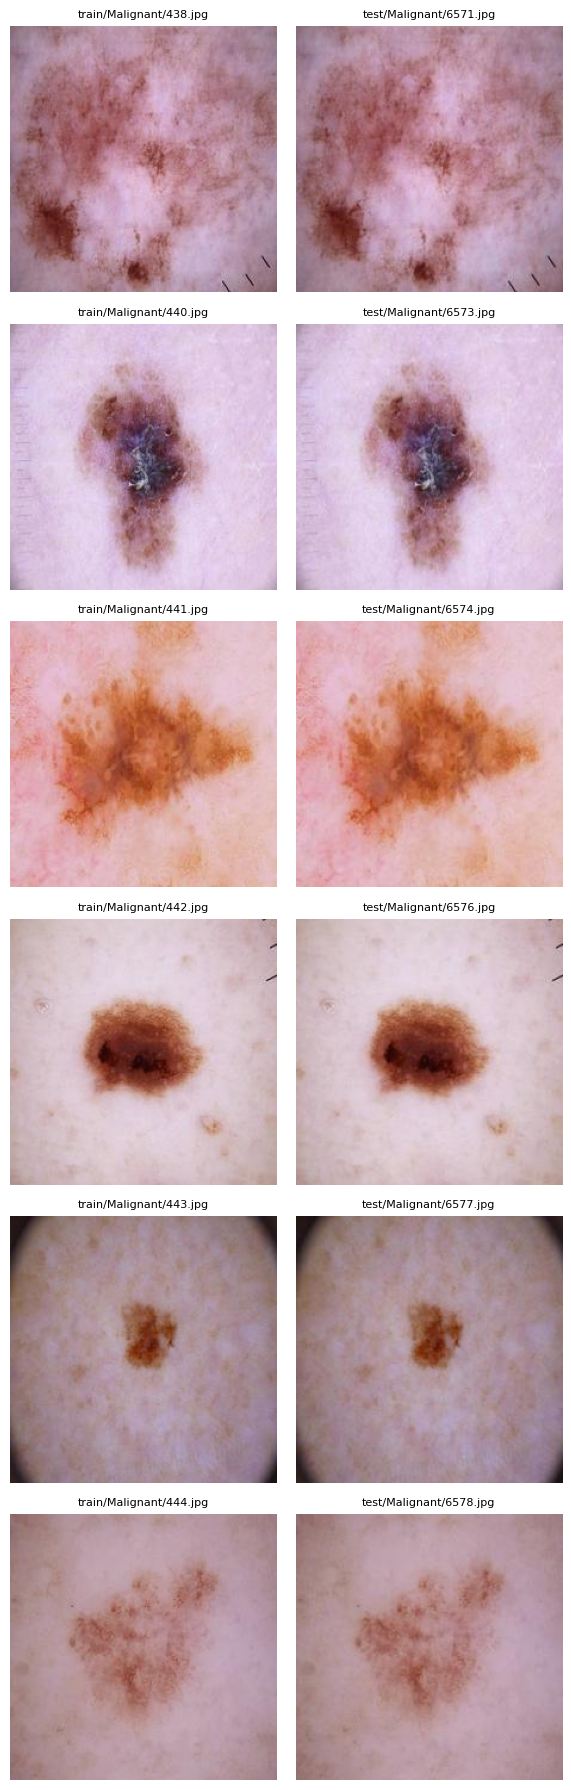

In [8]:
import matplotlib.pyplot as plt

sample_pairs = similarity[similarity.hamming_distance == 0].head(6)
fig, axes = plt.subplots(len(sample_pairs), 2, figsize=(6, 3 * len(sample_pairs)))
for i, (_, row) in enumerate(sample_pairs.iterrows()):
    img_a = Image.open(OUT.parent / row.path_a) if (OUT.parent / row.path_a).exists() else None
    # Ajustá la ruta base según cómo esté armado tu 'root' o 'audit' original
    for j, path in enumerate([row.path_a, row.path_b]):
        full_path = [p for p in audit.path if str(p).endswith(path)]
        if full_path:
            img = Image.open(full_path[0])
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            axes[i, j].set_title(path, fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# --- Aplicar el split sin réplicas (antes de la sección 4) ---
max_group = max(len(g) for g in groups.values())
print('Grupo más grande:', max_group)

lab = dict(zip(df.relative_path, df.label))
conflict_groups = [g for g in groups.values() if len({lab[p] for p in g}) > 1]
print('Grupos con etiquetas contradictorias:', len(conflict_groups))

df['subset_original'] = df['subset']
df['subset'] = df['subset_dedup']
df = df.drop(columns='subset_dedup')

manifest = df[['relative_path', 'part', 'label', 'subset', 'subset_original']].sort_values('relative_path')
manifest.to_csv(OUT / 'split_manifest_dedup.csv', index=False)
manifest_sha256 = hashlib.sha256((OUT / 'split_manifest_dedup.csv').read_bytes()).hexdigest()


train_info = df[df.subset == 'train'].copy()

audit_summary.update({
    'near_duplicate_groups': sum(1 for g in groups.values() if len(g) > 1),
    'images_reassigned': int((df.subset != df.subset_original).sum()),
    'max_group_size': max_group,
    'label_conflict_groups': len(conflict_groups),
    'manual_review': 'muestra visual: réplicas confirmadas; grupos reasignados',
})
(OUT / 'auditoria_datos.json').write_text(json.dumps(audit_summary, indent=2, ensure_ascii=False))

display(pd.crosstab(df['subset'], df['label']))

Grupo más grande: 1172
Grupos con etiquetas contradictorias: 22


label,Benign,Malignant
subset,,
test,754,398
train,5779,5417
val,756,775


## 4. Preparación de entradas

La media y desviación del color se describen usando exclusivamente las imágenes de entrenamiento. Para los dos modelos se utiliza la misma normalización de ImageNet y la misma entrada de 224 × 224 píxeles. Las transformaciones aleatorias se aplican en línea solo al entrenamiento; validación, prueba e inferencia conservan un tratamiento fijo. El redimensionado de la imagen completa evita recortar bordes de lesiones presentes en archivos ya reducidos a 224 × 224.

In [10]:
pixel_sum = np.zeros(3, dtype=np.float64)
square_sum = np.zeros(3, dtype=np.float64)
n_pixels = 0
for path in tqdm(train_info.path, desc='Estadísticas RGB de entrenamiento'):
    with Image.open(path) as image:
        pixels = np.asarray(image.convert('RGB'), dtype=np.float64) / 255.0
    pixel_sum += pixels.sum(axis=(0, 1))
    square_sum += np.square(pixels).sum(axis=(0, 1))
    n_pixels += pixels.shape[0] * pixels.shape[1]
mean_train = pixel_sum / n_pixels
std_train = np.sqrt(np.maximum(square_sum / n_pixels - mean_train ** 2, 0))
print('Media RGB (solo train):', np.round(mean_train, 6))
print('Desviación RGB global (solo train):', np.round(std_train, 6))

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0),
                                 interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class LesionDataset(Dataset):
    def __init__(self, info, transform):
        self.info = info.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.info)

    def __getitem__(self, index):
        item = self.info.iloc[index]
        with Image.open(item.path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, LABEL2IDX[item.label]

train_ds = LesionDataset(df[df.subset == 'train'], train_tf)
val_ds = LesionDataset(df[df.subset == 'val'], eval_tf)
test_ds = LesionDataset(df[df.subset == 'test'], eval_tf)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def training_loader():
    return DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2,
                      worker_init_fn=seed_worker,
                      generator=torch.Generator().manual_seed(SEED))

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
print('Entrenamiento, validación, prueba:', len(train_ds), len(val_ds), len(test_ds))

Estadísticas RGB de entrenamiento:   0%|          | 0/11196 [00:00<?, ?it/s]

Media RGB (solo train): [0.725635 0.559332 0.54399 ]
Desviación RGB global (solo train): [0.21326  0.20387  0.217215]
Entrenamiento, validación, prueba: 11196 1531 1152


## 5. Arquitecturas y reglas de selección

EfficientNet-B0 se adoptó como punto de partida por su tamaño moderado y por el primer prototipo funcional del equipo. ResNet-18 proporciona una comparación de otra familia de redes estudiada en la asignatura. Se emplean pesos preentrenados y, para cada arquitectura, una etapa con la base congelada seguida de ajuste completo. Se fijan semilla, particiones, aumentos, número de épocas y criterio de selección; la AUC de validación determina el mejor checkpoint y la arquitectura elegida. Se reportan además sensibilidad, especificidad, precisión, F1 y tiempos. La comparación no afirma que las dos arquitecturas tengan exactamente el mismo número de parámetros ni velocidad.

In [11]:
MODEL_NAMES = ('efficientnet_b0', 'resnet18')
EPOCHS_HEAD = 8
EPOCHS_FINETUNE = 6

def build_model(name, pretrained=True):
    if name == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        model = efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
        head = model.classifier
        base = model.features
    elif name == 'resnet18':
        weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        model = resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, 2)
        head = model.fc
        base = nn.ModuleList([module for module_name, module in model.named_children()
                              if module_name != 'fc'])
    else:
        raise ValueError(name)
    return model.to(DEVICE), head, base

def classify_metrics(y_true, probabilities, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {'roc_auc': float(roc_auc_score(y_true, probabilities)),
            'accuracy': float((tp + tn) / len(y_true)),
            'sensitivity': float(tp / (tp + fn)),
            'specificity': float(tn / (tn + fp)),
            'precision_malignant': float(precision_score(y_true, predictions, zero_division=0)),
            'f1_malignant': float(f1_score(y_true, predictions, zero_division=0)),
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}

loss_fn = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None, head=None, frozen_base=False):
    is_training = optimizer is not None
    model.train(is_training)
    if is_training and frozen_base:
        model.eval()  # También inmoviliza las estadísticas internas de BatchNorm.
        head.train()
    all_labels, all_probs = [], []
    total_loss = 0.0
    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(logits.softmax(1)[:, 1].detach().cpu().numpy())
    metrics = classify_metrics(all_labels, all_probs)
    metrics['loss'] = float(total_loss / len(loader.dataset))
    return metrics, np.asarray(all_labels), np.asarray(all_probs)

In [12]:
def fit_stage(name, stage, model, head, loader, epochs, lr, frozen_base):
    for parameter in model.parameters():
        parameter.requires_grad = not frozen_base
    if frozen_base:
        for parameter in head.parameters():
            parameter.requires_grad = True
    optimizer = AdamW([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-4)
    best_key = (-float('inf'), -float('inf'))
    best_row = None
    history = []
    ckpt = OUT / f'{name}_{stage}.pt'
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        train_metrics, _, _ = run_epoch(model, loader, optimizer=optimizer,
                                        head=head, frozen_base=frozen_base)
        val_metrics, _, _ = run_epoch(model, val_loader)
        row = {'model': name, 'stage': stage, 'epoch': epoch,
               'train_loss': train_metrics['loss'],
               **{f'val_{key}': value for key, value in val_metrics.items()}}
        history.append(row)
        key = (val_metrics['roc_auc'], val_metrics['f1_malignant'])
        if key > best_key:
            best_key = key
            best_row = row.copy()
            torch.save(model.state_dict(), ckpt)
        print(f"{name} {stage} {epoch:02d}/{epochs}: "
              f"val AUC={key[0]:.4f}, sensibilidad={val_metrics['sensitivity']:.4f}, "
              f"especificidad={val_metrics['specificity']:.4f}")
    best_row['stage_time_s'] = float(time.perf_counter() - start)
    best_row['checkpoint'] = str(ckpt)
    return best_row, history

all_histories = []
best_stages = []
for model_name in MODEL_NAMES:
    # Se restablece la semilla para que la comparación sea reproducible.
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    model, head, base = build_model(model_name, pretrained=True)
    first, hist_first = fit_stage(model_name, 'head', model, head,
                                  training_loader(), EPOCHS_HEAD, 1e-3, True)
    model.load_state_dict(torch.load(first['checkpoint'], map_location=DEVICE,
                                     weights_only=True))
    second, hist_second = fit_stage(model_name, 'finetuned', model, head,
                                    training_loader(), EPOCHS_FINETUNE, 1e-5, False)
    all_histories.extend(hist_first + hist_second)
    best_stages.extend([first, second])
    del model, head, base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

history_df = pd.DataFrame(all_histories)
stage_df = pd.DataFrame(best_stages)
history_df.to_csv(OUT / 'validation_history.csv', index=False)
stage_df.to_csv(OUT / 'model_selection.csv', index=False)
display(stage_df[['model','stage','epoch','val_roc_auc','val_sensitivity',
                  'val_specificity','val_f1_malignant','stage_time_s']])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 212MB/s]


efficientnet_b0 head 01/8: val AUC=0.9369, sensibilidad=0.8981, especificidad=0.8267
efficientnet_b0 head 02/8: val AUC=0.9424, sensibilidad=0.9110, especificidad=0.8373
efficientnet_b0 head 03/8: val AUC=0.9419, sensibilidad=0.8813, especificidad=0.8783
efficientnet_b0 head 04/8: val AUC=0.9431, sensibilidad=0.9006, especificidad=0.8598
efficientnet_b0 head 05/8: val AUC=0.9411, sensibilidad=0.9252, especificidad=0.8161
efficientnet_b0 head 06/8: val AUC=0.9428, sensibilidad=0.9032, especificidad=0.8585
efficientnet_b0 head 07/8: val AUC=0.9439, sensibilidad=0.8877, especificidad=0.8730
efficientnet_b0 head 08/8: val AUC=0.9417, sensibilidad=0.8955, especificidad=0.8585
efficientnet_b0 finetuned 01/6: val AUC=0.9106, sensibilidad=0.7884, especificidad=0.8743
efficientnet_b0 finetuned 02/6: val AUC=0.9230, sensibilidad=0.8168, especificidad=0.8783
efficientnet_b0 finetuned 03/6: val AUC=0.9308, sensibilidad=0.8477, especificidad=0.8638
efficientnet_b0 finetuned 04/6: val AUC=0.9338, se

100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


resnet18 head 01/8: val AUC=0.9308, sensibilidad=0.9239, especificidad=0.7540
resnet18 head 02/8: val AUC=0.9342, sensibilidad=0.8723, especificidad=0.8439
resnet18 head 03/8: val AUC=0.9369, sensibilidad=0.9187, especificidad=0.8042
resnet18 head 04/8: val AUC=0.9368, sensibilidad=0.8955, especificidad=0.8386
resnet18 head 05/8: val AUC=0.9371, sensibilidad=0.9329, especificidad=0.7778
resnet18 head 06/8: val AUC=0.9359, sensibilidad=0.8813, especificidad=0.8466
resnet18 head 07/8: val AUC=0.9358, sensibilidad=0.8516, especificidad=0.8704
resnet18 head 08/8: val AUC=0.9368, sensibilidad=0.8710, especificidad=0.8571
resnet18 finetuned 01/6: val AUC=0.9346, sensibilidad=0.8723, especificidad=0.8545
resnet18 finetuned 02/6: val AUC=0.9414, sensibilidad=0.8542, especificidad=0.8902
resnet18 finetuned 03/6: val AUC=0.9486, sensibilidad=0.8271, especificidad=0.9246
resnet18 finetuned 04/6: val AUC=0.9507, sensibilidad=0.8787, especificidad=0.8849
resnet18 finetuned 05/6: val AUC=0.9536, sen

,model,stage,epoch,val_roc_auc,val_sensitivity,val_specificity,val_f1_malignant,stage_time_s
0,efficientnet_b0,head,7,0.943938,0.887742,0.873016,0.882617,512.449253
1,efficientnet_b0,finetuned,6,0.941493,0.878710,0.859788,0.871959,463.694077
2,resnet18,head,5,0.937139,0.932903,0.777778,0.867947,490.842251
3,resnet18,finetuned,6,0.957027,0.910968,0.875661,0.896508,427.990082


## 6. Selección en validación y umbral de investigación

La arquitectura y la etapa con mayor AUC de validación se seleccionan antes de consultar la prueba. Para ilustrar la prioridad de detectar lesiones etiquetadas como malignas, se fija una sensibilidad objetivo de 0,90 en validación y, entre los umbrales que la alcanzan, se elige el de mayor especificidad. Este objetivo es un criterio académico previo a la prueba: no es una recomendación clínica ni una probabilidad de enfermedad calibrada.

In [13]:
winner = stage_df.sort_values(['val_roc_auc','val_f1_malignant'],
                              ascending=False).iloc[0]
selected_name = str(winner['model'])
model, _, _ = build_model(selected_name, pretrained=False)
model.load_state_dict(torch.load(winner['checkpoint'], map_location=DEVICE,
                                 weights_only=True))
_, val_labels, val_probs = run_epoch(model, val_loader)
TARGET_SENSITIVITY = 0.90
thresholds = np.unique(np.r_[0.0, val_probs, 1.0])
feasible = []
for threshold in thresholds:
    metrics = classify_metrics(val_labels, val_probs, float(threshold))
    if metrics['sensitivity'] >= TARGET_SENSITIVITY:
        feasible.append((metrics['specificity'], float(threshold)))
selected_threshold = max(feasible)[1]
val_selected = classify_metrics(val_labels, val_probs, selected_threshold)
print('Modelo seleccionado:', selected_name, '| etapa:', winner['stage'])
print('Umbral elegido con validación:', selected_threshold)
print('Validación a umbral 0,5:', classify_metrics(val_labels, val_probs, 0.5))
print('Validación al umbral elegido:', val_selected)

checkpoint = {'model_name': selected_name,
              'state_dict': model.state_dict(),
              'threshold': selected_threshold,
              'image_size': IMG_SIZE,
              'mean': IMAGENET_MEAN, 'std': IMAGENET_STD,
              'label_to_index': LABEL2IDX,
              'dataset_handle': DATASET_HANDLE,
              'manifest_sha256': manifest_sha256}
torch.save(checkpoint, OUT / 'model_final.pt')

Modelo seleccionado: resnet18 | etapa: finetuned
Umbral elegido con validación: 0.5762757658958435
Validación a umbral 0,5: {'roc_auc': 0.957026796381635, 'accuracy': 0.8935336381450033, 'sensitivity': 0.9109677419354839, 'specificity': 0.8756613756613757, 'precision_malignant': 0.8825, 'f1_malignant': 0.8965079365079365, 'tn': 662, 'fp': 94, 'fn': 69, 'tp': 706}
Validación al umbral elegido: {'roc_auc': 0.957026796381635, 'accuracy': 0.8961463096015676, 'sensitivity': 0.9006451612903226, 'specificity': 0.8915343915343915, 'precision_malignant': 0.8948717948717949, 'f1_malignant': 0.8977491961414791, 'tn': 674, 'fp': 82, 'fn': 77, 'tp': 698}


## 7. Evaluación única en prueba

Se aplican el modelo y el umbral definidos en validación sin modificarlos a partir de la prueba. La prueba provista por la fuente ya se había visualizado y usado para evaluar una primera versión del modelo en el desarrollo anterior; por tanto, se informa ese antecedente como límite de independencia. Si se requiere una medición estrictamente nueva, será necesario un conjunto externo con origen y etiquetas verificables.

Prueba, umbral fijo 0,5: {'roc_auc': 0.9769370726310598, 'accuracy': 0.9088541666666666, 'sensitivity': 0.9396984924623115, 'specificity': 0.8925729442970822, 'precision_malignant': 0.8219780219780219, 'f1_malignant': 0.876905041031653, 'tn': 673, 'fp': 81, 'fn': 24, 'tp': 374}
Prueba, umbral fijado en validación: {'roc_auc': 0.9769370726310598, 'accuracy': 0.9184027777777778, 'sensitivity': 0.9271356783919598, 'specificity': 0.9137931034482759, 'precision_malignant': 0.8502304147465438, 'f1_malignant': 0.8870192307692307, 'tn': 689, 'fp': 65, 'fn': 29, 'tp': 369}


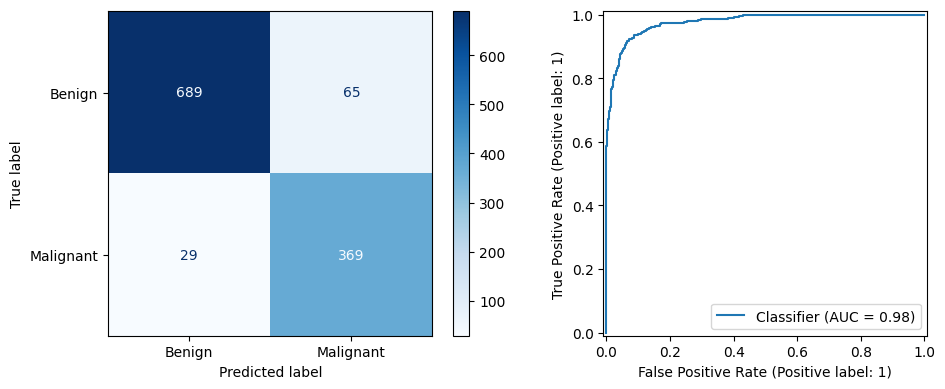

In [14]:
test_default, test_labels, test_probs = run_epoch(model, test_loader)
test_selected = classify_metrics(test_labels, test_probs, selected_threshold)
test_default.pop('loss', None)
test_selected.pop('loss', None)
print('Prueba, umbral fijo 0,5:', test_default)
print('Prueba, umbral fijado en validación:', test_selected)

predictions = df[df.subset == 'test'][['relative_path','label']].reset_index(drop=True).copy()
predictions['score_malignant'] = test_probs
predictions['predicted_label'] = np.where(test_probs >= selected_threshold,
                                          'Malignant', 'Benign')
predictions.to_csv(OUT / 'test_predictions.csv', index=False)

final_metrics = {'selected_model': selected_name,
                 'selected_stage': str(winner['stage']),
                 'threshold_from_validation': selected_threshold,
                 'validation_target_sensitivity': TARGET_SENSITIVITY,
                 'test_at_0_5': test_default,
                 'test_at_selected_threshold': test_selected,
                 'n_train': len(train_ds), 'n_val': len(val_ds), 'n_test': len(test_ds),
                 'audit': audit_summary,
                 'test_was_previously_inspected': True}
(OUT / 'metrics_final.json').write_text(
    json.dumps(final_metrics, indent=2, ensure_ascii=False), encoding='utf-8')
pd.DataFrame([{'threshold_type': key, **value} for key, value in
              [('0.5', test_default), ('validation', test_selected)]]).to_csv(
    OUT / 'metrics_final.csv', index=False)
model_hash = hashlib.sha256((OUT / 'model_final.pt').read_bytes()).hexdigest()
environment = {'python': platform.python_version(), 'torch': torch.__version__,
               'torchvision': torchvision.__version__, 'numpy': np.__version__,
               'pandas': pd.__version__, 'sklearn': sklearn.__version__,
               'Pillow': PIL.__version__, 'kagglehub': md.version('kagglehub'),
               'device': str(DEVICE), 'dataset_url': DATASET_URL,
               'dataset_path': str(root), 'dataset_version_from_path': dataset_version,
               'dataset_primary_source': 'pendiente de verificación',
               'dataset_license': 'pendiente de verificación',
               'model_sha256': model_hash, 'split_manifest_sha256': manifest_sha256,
               'seed': SEED}
(OUT / 'environment.json').write_text(json.dumps(environment, indent=2, ensure_ascii=False))

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(test_labels, test_probs >= selected_threshold,
    labels=[0, 1], display_labels=['Benign','Malignant'], cmap='Blues', ax=axes[0])
RocCurveDisplay.from_predictions(test_labels, test_probs, ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Interpretación de errores y prevalencia

La matriz permite cuantificar los falsos negativos de la clase maligna y los falsos positivos de la clase benigna. La prueba tiene clases equilibradas por construcción; la proporción de predicciones positivas correctas puede cambiar mucho en poblaciones donde los casos malignos sean menos frecuentes. El ejemplo numérico siguiente cambia solo la prevalencia hipotética y no estima el desempeño clínico real.

In [15]:
def positive_predictive_value(sensitivity, specificity, prevalence):
    numerator = sensitivity * prevalence
    denominator = numerator + (1 - specificity) * (1 - prevalence)
    return numerator / denominator if denominator else float('nan')

prevalence_examples = pd.DataFrame([
    {'assumed_prevalence': p,
     'illustrative_positive_precision': positive_predictive_value(
         test_selected['sensitivity'], test_selected['specificity'], p)}
    for p in (0.05, 0.10, 0.50)
])
display(prevalence_examples)
print('Falsos negativos observados en la prueba:', test_selected['fn'])
print('Falsos positivos observados en la prueba:', test_selected['fp'])

misses = predictions[(predictions.label == 'Malignant') &
                      (predictions.predicted_label == 'Benign')]
false_alarms = predictions[(predictions.label == 'Benign') &
                           (predictions.predicted_label == 'Malignant')]
display(misses.head(5))
display(false_alarms.head(5))

,assumed_prevalence,illustrative_positive_precision
0,0.05,0.361447
1,0.10,0.544414
2,0.50,0.914928


Falsos negativos observados en la prueba: 29
Falsos positivos observados en la prueba: 65


,relative_path,label,score_malignant,predicted_label
824,test/Malignant/5682.jpg,Malignant,0.465641,Benign
873,test/Malignant/5780.jpg,Malignant,0.050507,Benign
889,test/Malignant/5815.jpg,Malignant,0.535650,Benign
897,test/Malignant/5836.jpg,Malignant,0.293859,Benign
908,test/Malignant/5865.jpg,Malignant,0.415953,Benign


,relative_path,label,score_malignant,predicted_label
7,test/Benign/6302.jpg,Benign,0.804696,Malignant
51,test/Benign/6359.jpg,Benign,0.877961,Malignant
84,test/Benign/6400.jpg,Benign,0.590506,Malignant
94,test/Benign/6412.jpg,Benign,0.921772,Malignant
127,test/Benign/6455.jpg,Benign,0.886255,Malignant


In [16]:
paper = f'''## Resultados del prototipo (borrador para adaptar al formato IEEE)

Se compararon EfficientNet-B0 y ResNet-18 preentrenadas en la misma partición ({len(train_ds)} entrenamiento, {len(val_ds)} validación y {len(test_ds)} prueba). Según la AUC de validación se seleccionó {selected_name} en la etapa {winner['stage']}; el umbral {selected_threshold:.4f} se fijó con validación para alcanzar al menos {TARGET_SENSITIVITY:.0%} de sensibilidad en ese conjunto. En prueba, la AUC fue {test_selected['roc_auc']:.3f}, la exactitud {test_selected['accuracy']:.3f}, la sensibilidad de la clase maligna {test_selected['sensitivity']:.3f}, la especificidad {test_selected['specificity']:.3f} y el F1 de la clase maligna {test_selected['f1_malignant']:.3f}. La matriz de confusión (verdadero benigno, falso positivo, falso negativo, verdadero maligno) fue ({test_selected['tn']}, {test_selected['fp']}, {test_selected['fn']}, {test_selected['tp']}). Se observaron {test_selected['fn']} falsos negativos de la clase maligna.

La muestra de prueba está equilibrada por construcción. Si se mantuvieran hipotéticamente la misma sensibilidad y especificidad con una prevalencia de 5%, la precisión de las predicciones positivas sería {positive_predictive_value(test_selected['sensitivity'], test_selected['specificity'], 0.05):.3f}; este cálculo ilustra el efecto de la prevalencia y no representa una medición clínica. Las limitaciones incluyen ausencia de identificadores de paciente o lesión para asegurar particiones independientes, candidatos visualmente similares pendientes de revisión, procedencia y licencia primaria por confirmar, sesgo de dominio hacia las imágenes del conjunto y consulta previa de la prueba durante el desarrollo. El sistema se presenta como prototipo académico.

La elección del modelo se basó en validación. Los puntajes de ImageNet y el número de parámetros motivaron la comparación de arquitecturas, pero no sustituyen la evaluación en este conjunto de lesiones.
'''
(OUT / 'resultados_para_paper.md').write_text(paper, encoding='utf-8')
print(paper)

## Resultados del prototipo (borrador para adaptar al formato IEEE)

Se compararon EfficientNet-B0 y ResNet-18 preentrenadas en la misma partición (11196 entrenamiento, 1531 validación y 1152 prueba). Según la AUC de validación se seleccionó resnet18 en la etapa finetuned; el umbral 0.5763 se fijó con validación para alcanzar al menos 90% de sensibilidad en ese conjunto. En prueba, la AUC fue 0.977, la exactitud 0.918, la sensibilidad de la clase maligna 0.927, la especificidad 0.914 y el F1 de la clase maligna 0.887. La matriz de confusión (verdadero benigno, falso positivo, falso negativo, verdadero maligno) fue (689, 65, 29, 369). Se observaron 29 falsos negativos de la clase maligna.

La muestra de prueba está equilibrada por construcción. Si se mantuvieran hipotéticamente la misma sensibilidad y especificidad con una prevalencia de 5%, la precisión de las predicciones positivas sería 0.361; este cálculo ilustra el efecto de la prevalencia y no representa una medición clínica. Las 

## 9. Inferencia demostrativa

Se carga el checkpoint seleccionado y se aplica exactamente la misma preparación que en validación y prueba. La celda siguiente permite evaluar una imagen dermatoscópica compatible con el conjunto; se ejecuta de forma opcional para evitar que la ejecución completa del cuaderno se detenga esperando una carga manual. El puntaje del modelo no es una probabilidad clínica calibrada.

In [17]:
def predict_single(image_path, checkpoint_path=OUT / 'model_final.pt'):
    bundle = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    inference_model, _, _ = build_model(bundle['model_name'], pretrained=False)
    inference_model.load_state_dict(bundle['state_dict'])
    inference_model.eval()
    with Image.open(image_path) as image:
        tensor = eval_tf(image.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.inference_mode():
        score = inference_model(tensor).softmax(1)[0, 1].item()
    result = {'label': 'Malignant' if score >= bundle['threshold'] else 'Benign',
              'score_malignant': score, 'threshold': bundle['threshold']}
    del inference_model
    return result

RUN_UPLOAD_DEMO = False
example = df[df.subset == 'val'].iloc[0]
print('Ejemplo de validación:', example.relative_path,
      '| etiqueta original:', example.label,
      '| salida:', predict_single(example.path))
if RUN_UPLOAD_DEMO:
    from google.colab import files
    uploaded = files.upload()
    for filename in uploaded:
        print(filename, predict_single(filename))
else:
    print('Para probar una imagen propia, activar RUN_UPLOAD_DEMO y ejecutar esta celda.')

Ejemplo de validación: train/Benign/1001.jpg | etiqueta original: Benign | salida: {'label': 'Benign', 'score_malignant': 0.0038726271595805883, 'threshold': 0.5762757658958435}
Para probar una imagen propia, activar RUN_UPLOAD_DEMO y ejecutar esta celda.


In [18]:
def bootstrap_metrics(y, p, thr, n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    res = {'auc': [], 'sensibilidad': [], 'especificidad': []}
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        m = classify_metrics(y[i], p[i], thr)
        res['auc'].append(m['roc_auc'])
        res['sensibilidad'].append(m['sensitivity'])
        res['especificidad'].append(m['specificity'])
    return {k: np.percentile(v, [2.5, 97.5]).round(3).tolist() for k, v in res.items()}

print('IC 95 % (prueba):', bootstrap_metrics(test_labels, test_probs, selected_threshold))

IC 95 % (prueba): {'auc': [0.969, 0.984], 'sensibilidad': [0.902, 0.951], 'especificidad': [0.892, 0.934]}


In [19]:
def profile(name, runs=100):
    m, _, _ = build_model(name, pretrained=False)
    m.eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.inference_mode():
        for _ in range(10): m(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(runs): m(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) / runs * 1000
    params = sum(p.numel() for p in m.parameters()) / 1e6
    del m
    return {'model': name, 'params_M': round(params, 2), 'latency_ms': round(ms, 1)}

display(pd.DataFrame([profile(n) for n in MODEL_NAMES]))

,model,params_M,latency_ms
0,efficientnet_b0,4.01,7.5
1,resnet18,11.18,3.7


## 10. Segmentación

In [20]:
seg_path = Path(kagglehub.dataset_download(
    'tschandl/isic2018-challenge-task1-data-segmentation'
))
print('Ruta local:', seg_path)
for root_dir, dirs, files in os.walk(seg_path):
    level = str(root_dir).replace(str(seg_path), '').count(os.sep)
    print('  ' * level + os.path.basename(root_dir) + f'/  ({len(files)} archivos)')
    if level > 2:
        dirs.clear()

100%|██████████| 12.9G/12.9G [10:29<00:00, 22.0MB/s]

Extracting files...


Ruta local: /root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1
1/  (0 archivos)
  ISIC2018_Task1-2_Test_Input/  (1002 archivos)
  ISIC2018_Task1-2_Training_Input/  (2596 archivos)
  ISIC2018_Task1-2_Validation_Input/  (102 archivos)
    .ipynb_checkpoints/  (4 archivos)
  ISIC2018_Task1_Training_GroundTruth/  (2596 archivos)


In [21]:
train_images_dir = seg_path / 'ISIC2018_Task1-2_Training_Input'
train_masks_dir = seg_path / 'ISIC2018_Task1_Training_GroundTruth'

image_files = sorted([f for f in os.listdir(train_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
mask_files = sorted([f for f in os.listdir(train_masks_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print('Total imágenes:', len(image_files))
print('Total máscaras:', len(mask_files))
print('\nPrimeros 5 nombres de imagen:', image_files[:5])
print('Primeros 5 nombres de máscara:', mask_files[:5])

# Archivos que no son imagen/máscara (licencias, metadatos, etc.)
other_train = [f for f in os.listdir(train_images_dir) if not f.lower().endswith(('.jpg', '.jpeg', '.png'))]
other_masks = [f for f in os.listdir(train_masks_dir) if not f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print('\nOtros archivos en Training_Input:', other_train)
print('Otros archivos en Training_GroundTruth:', other_masks)

Total imágenes: 2594
Total máscaras: 2594

Primeros 5 nombres de imagen: ['ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000003.jpg', 'ISIC_0000004.jpg', 'ISIC_0000006.jpg']
Primeros 5 nombres de máscara: ['ISIC_0000000_segmentation.png', 'ISIC_0000001_segmentation.png', 'ISIC_0000003_segmentation.png', 'ISIC_0000004_segmentation.png', 'ISIC_0000006_segmentation.png']

Otros archivos en Training_Input: ['ATTRIBUTION.txt', 'LICENSE.txt']
Otros archivos en Training_GroundTruth: ['ATTRIBUTION.txt', 'LICENSE.txt']


#11. Split

In [22]:
seg_images = sorted(train_images_dir.glob('ISIC_*.jpg'))
seg_pairs = []
for img_path in seg_images:
    mask_path = train_masks_dir / (img_path.stem + '_segmentation.png')
    if mask_path.exists():
        seg_pairs.append({'image_path': str(img_path), 'mask_path': str(mask_path),
                          'case_id': img_path.stem})

seg_df = pd.DataFrame(seg_pairs)
print('Pares imagen-máscara:', len(seg_df))

seg_train_idx, seg_temp_idx = train_test_split(seg_df.index, test_size=0.2, random_state=SEED)
seg_val_idx, seg_test_idx = train_test_split(seg_temp_idx, test_size=0.5, random_state=SEED)
seg_df['subset'] = 'train'
seg_df.loc[seg_val_idx, 'subset'] = 'val'
seg_df.loc[seg_test_idx, 'subset'] = 'test'
print(seg_df.subset.value_counts())

seg_out = OUT / 'segmentation'
seg_out.mkdir(exist_ok=True)
seg_df.to_csv(seg_out / 'seg_manifest.csv', index=False)

# Guardar procedencia y licencia junto con el resto de la documentación
import shutil
shutil.copy(train_images_dir / 'LICENSE.txt', seg_out / 'ISIC2018_LICENSE.txt')
shutil.copy(train_images_dir / 'ATTRIBUTION.txt', seg_out / 'ISIC2018_ATTRIBUTION.txt')
print((seg_out / 'ISIC2018_LICENSE.txt').read_text()[:500])

Pares imagen-máscara: 2594
subset
train    2075
test      260
val       259
Name: count, dtype: int64
Creative Commons Legal Code

CC0 1.0 Universal

    CREATIVE COMMONS CORPORATION IS NOT A LAW FIRM AND DOES NOT PROVIDE
    LEGAL SERVICES. DISTRIBUTION OF THIS DOCUMENT DOES NOT CREATE AN
    ATTORNEY-CLIENT RELATIONSHIP. CREATIVE COMMONS PROVIDES THIS
    INFORMATION ON AN "AS-IS" BASIS. CREATIVE COMMONS MAKES NO WARRANTIES
    REGARDING THE USE OF THIS DOCUMENT OR THE INFORMATION OR WORKS
    PROVIDED HEREUNDER, AND DISCLAIMS LIABILITY FOR DAMAGES RESULTING FROM
    THE USE OF THIS DOCUMENT O


#12. Dataset con augmentation

In [23]:
!pip install -q albumentations segmentation-models-pytorch

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import cv2

SEG_SIZE = 256

seg_train_tf = A.Compose([
    A.Resize(SEG_SIZE, SEG_SIZE, interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.7, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
seg_eval_tf = A.Compose([
    A.Resize(SEG_SIZE, SEG_SIZE, interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class SegDataset(Dataset):
    def __init__(self, info, transform):
        self.info = info.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.info)

    def __getitem__(self, idx):
        row = self.info.iloc[idx]
        image = np.array(Image.open(row.image_path).convert('RGB'))
        mask = np.array(Image.open(row.mask_path).convert('L'))
        mask = (mask > 127).astype(np.float32)
        augmented = self.transform(image=image, mask=mask)
        return augmented['image'], augmented['mask'].unsqueeze(0)

seg_train_ds = SegDataset(seg_df[seg_df.subset == 'train'], seg_train_tf)
seg_val_ds = SegDataset(seg_df[seg_df.subset == 'val'], seg_eval_tf)
seg_test_ds = SegDataset(seg_df[seg_df.subset == 'test'], seg_eval_tf)

seg_train_loader = DataLoader(seg_train_ds, batch_size=16, shuffle=True, num_workers=2,
                              worker_init_fn=seed_worker, generator=torch.Generator().manual_seed(SEED))
seg_val_loader = DataLoader(seg_val_ds, batch_size=16, shuffle=False, num_workers=2)
seg_test_loader = DataLoader(seg_test_ds, batch_size=16, shuffle=False, num_workers=2)
print(len(seg_train_ds), len(seg_val_ds), len(seg_test_ds))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.9 MB/s eta 0:00:00
2075 259 260


#13. Modelo U-Net y pérdida

In [24]:
seg_model = smp.Unet(encoder_name='resnet18', encoder_weights='imagenet',
                     in_channels=3, classes=1, activation=None).to(DEVICE)

dice_loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss_fn = nn.BCEWithLogitsLoss()

def seg_loss(logits, masks):
    return 0.5 * dice_loss_fn(logits, masks) + 0.5 * bce_loss_fn(logits, masks)

def seg_metrics(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = ((preds + masks) >= 1).float().sum(dim=(1, 2, 3))
    dice_num = 2 * intersection
    dice_den = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    iou = (intersection / union.clamp(min=1e-7)).mean().item()
    dice = (dice_num / dice_den.clamp(min=1e-7)).mean().item()
    return iou, dice

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

#14. Entrenamiento

In [25]:
def run_seg_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, total_iou, total_dice, n_batches = 0.0, 0.0, 0.0, 0
    with torch.set_grad_enabled(is_training):
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss = seg_loss(logits, masks)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            iou, dice = seg_metrics(logits.detach(), masks)
            total_loss += loss.item(); total_iou += iou; total_dice += dice; n_batches += 1
    return {'loss': total_loss / n_batches, 'iou': total_iou / n_batches, 'dice': total_dice / n_batches}

SEG_EPOCHS = 12
seg_optimizer = AdamW(seg_model.parameters(), lr=1e-4, weight_decay=1e-5)
best_dice = -1
seg_history = []
seg_ckpt = seg_out / 'unet_resnet18.pt'

for epoch in range(1, SEG_EPOCHS + 1):
    train_m = run_seg_epoch(seg_model, seg_train_loader, seg_optimizer)
    val_m = run_seg_epoch(seg_model, seg_val_loader)
    seg_history.append({'epoch': epoch, **{f'train_{k}': v for k, v in train_m.items()},
                        **{f'val_{k}': v for k, v in val_m.items()}})
    if val_m['dice'] > best_dice:
        best_dice = val_m['dice']
        torch.save(seg_model.state_dict(), seg_ckpt)
    print(f"Época {epoch:02d}/{SEG_EPOCHS}: val IoU={val_m['iou']:.4f}, val Dice={val_m['dice']:.4f}")

pd.DataFrame(seg_history).to_csv(seg_out / 'seg_history.csv', index=False)

Época 01/12: val IoU=0.7720, val Dice=0.8507
Época 02/12: val IoU=0.7823, val Dice=0.8617
Época 03/12: val IoU=0.7776, val Dice=0.8602
Época 04/12: val IoU=0.8013, val Dice=0.8740
Época 05/12: val IoU=0.7858, val Dice=0.8662
Época 06/12: val IoU=0.7966, val Dice=0.8736
Época 07/12: val IoU=0.8107, val Dice=0.8832
Época 08/12: val IoU=0.8085, val Dice=0.8786
Época 09/12: val IoU=0.8042, val Dice=0.8765
Época 10/12: val IoU=0.8156, val Dice=0.8831
Época 11/12: val IoU=0.8168, val Dice=0.8868
Época 12/12: val IoU=0.8233, val Dice=0.8903


#15. Curvas de entrenamietno

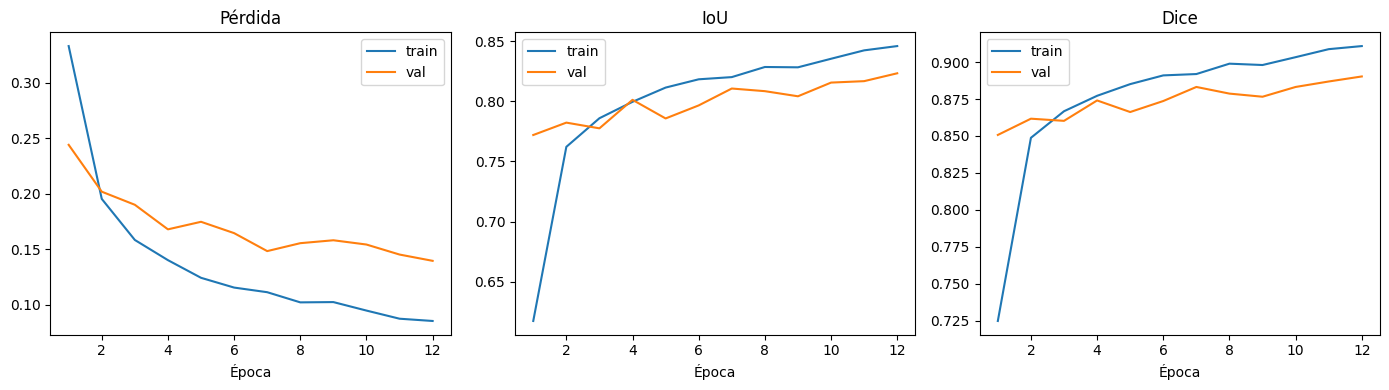

epoch       12.000000
val_iou      0.823318
val_dice     0.890256
Name: 11, dtype: float64


In [26]:
hist = pd.read_csv(seg_out / 'seg_history.csv')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'iou', 'dice'], ['Pérdida', 'IoU', 'Dice']):
    ax.plot(hist.epoch, hist[f'train_{metric}'], label='train')
    ax.plot(hist.epoch, hist[f'val_{metric}'], label='val')
    ax.set_title(title); ax.set_xlabel('Época'); ax.legend()
plt.tight_layout()
plt.savefig(seg_out / 'curvas_segmentacion.png', dpi=200)
plt.show()
print(hist.loc[hist.val_dice.idxmax(), ['epoch', 'val_iou', 'val_dice']])

#16. Evaluavión en test por imagen

In [27]:
seg_model.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE, weights_only=True))
seg_model.eval()

def per_image_metrics(logits, masks, threshold=0.5):
    preds = (torch.sigmoid(logits) >= threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = ((preds + masks) >= 1).float().sum(dim=(1, 2, 3))
    iou = inter / union.clamp(min=1e-7)
    dice = 2 * inter / (preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))).clamp(min=1e-7)
    return iou.cpu().numpy(), dice.cpu().numpy()

all_iou, all_dice, all_probs = [], [], []
with torch.inference_mode():
    for images, masks in seg_test_loader:
        logits = seg_model(images.to(DEVICE))
        iou, dice = per_image_metrics(logits, masks.to(DEVICE))
        all_iou.extend(iou); all_dice.extend(dice)

seg_test_df = seg_df[seg_df.subset == 'test'].reset_index(drop=True).copy()
seg_test_df['iou'] = all_iou
seg_test_df['dice'] = all_dice

def bootstrap_ci(values, n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n)]
    return np.percentile(means, [2.5, 97.5])

iou_ci = bootstrap_ci(seg_test_df.iou.values)
dice_ci = bootstrap_ci(seg_test_df.dice.values)
print(f"Test (n={len(seg_test_df)})")
print(f"IoU : media={seg_test_df.iou.mean():.4f}  mediana={seg_test_df.iou.median():.4f}  IC95%=[{iou_ci[0]:.4f}, {iou_ci[1]:.4f}]")
print(f"Dice: media={seg_test_df.dice.mean():.4f}  mediana={seg_test_df.dice.median():.4f}  IC95%=[{dice_ci[0]:.4f}, {dice_ci[1]:.4f}]")
print("Imágenes con Dice < 0.5:", (seg_test_df.dice < 0.5).sum(), f"({(seg_test_df.dice < 0.5).mean():.1%})")

seg_test_df.to_csv(seg_out / 'seg_test_per_image.csv', index=False)

Test (n=260)
IoU : media=0.8127  mediana=0.8729  IC95%=[0.7911, 0.8321]
Dice: media=0.8826  mediana=0.9322  IC95%=[0.8634, 0.8989]
Imágenes con Dice < 0.5: 10 (3.8%)


#17. Distribución y latencia

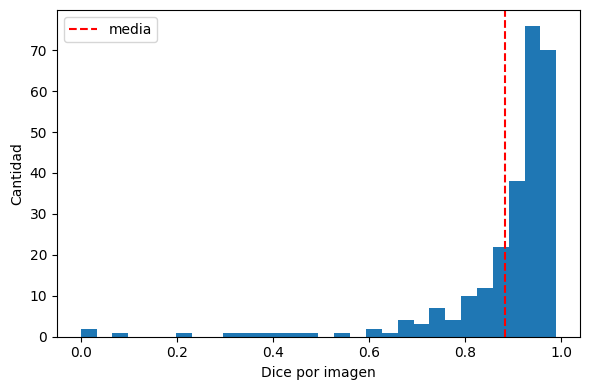

Latencia: 9.0 ms/imagen en cuda | Parámetros: 14.3 M


In [28]:
plt.figure(figsize=(6, 4))
plt.hist(seg_test_df.dice, bins=30)
plt.axvline(seg_test_df.dice.mean(), color='r', linestyle='--', label='media')
plt.xlabel('Dice por imagen'); plt.ylabel('Cantidad'); plt.legend()
plt.tight_layout(); plt.savefig(seg_out / 'hist_dice_test.png', dpi=200); plt.show()

# Latencia de inferencia (la consigna pide reportarla)
dummy = torch.randn(1, 3, SEG_SIZE, SEG_SIZE).to(DEVICE)
with torch.inference_mode():
    for _ in range(10): seg_model(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(100): seg_model(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
latency_ms = (time.perf_counter() - t0) / 100 * 1000
n_params = sum(p.numel() for p in seg_model.parameters())
print(f"Latencia: {latency_ms:.1f} ms/imagen en {DEVICE} | Parámetros: {n_params/1e6:.1f} M")

#18. Mejores, medianos y peores

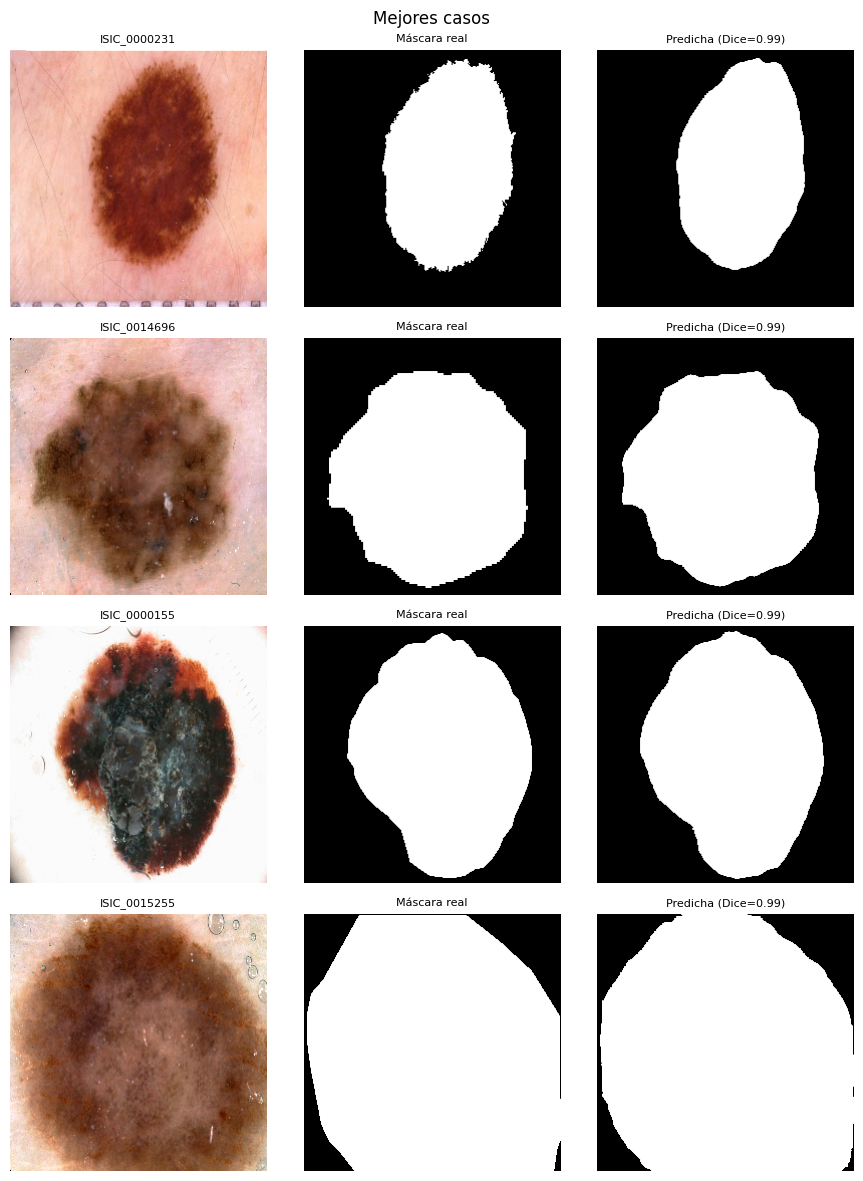

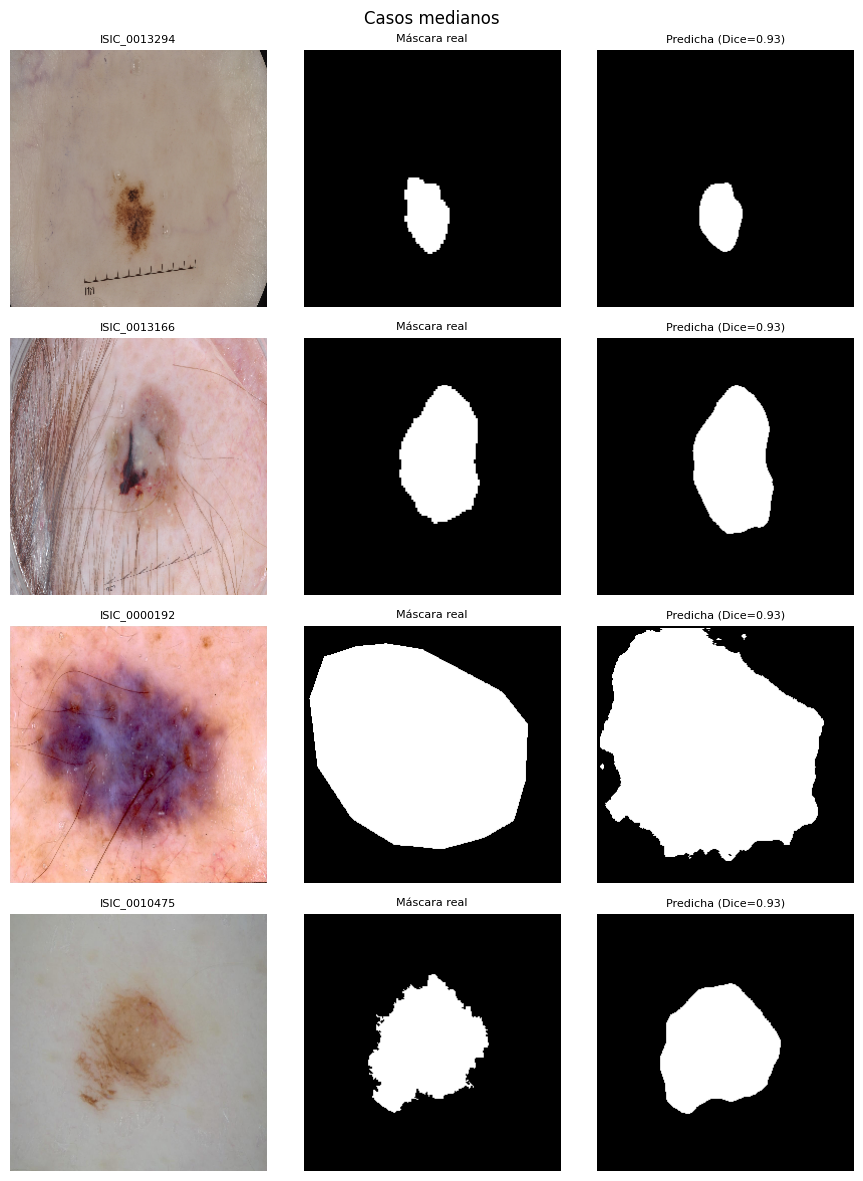

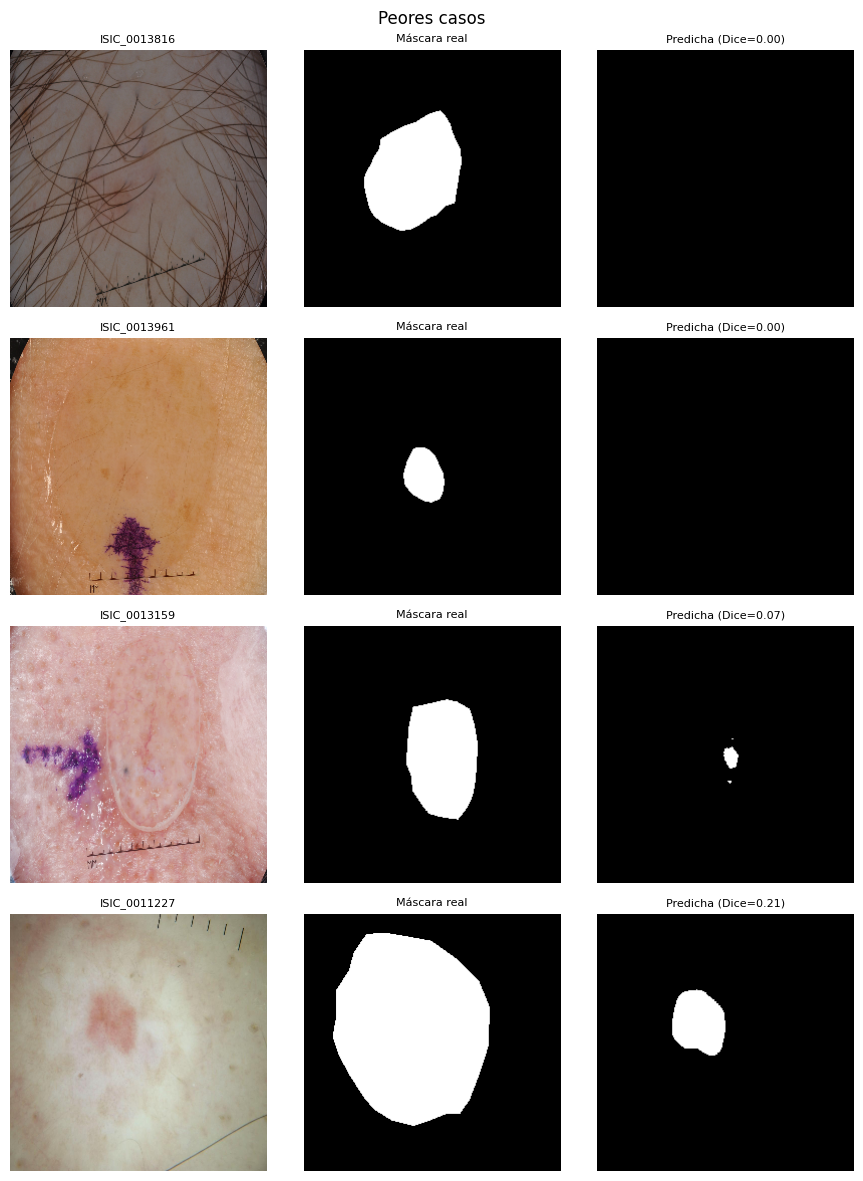

In [29]:
def show_cases(df_cases, title, fname):
    fig, axes = plt.subplots(len(df_cases), 3, figsize=(9, 3 * len(df_cases)))
    for i, (_, r) in enumerate(df_cases.iterrows()):
        image = np.array(Image.open(r.image_path).convert('RGB'))
        mask = np.array(Image.open(r.mask_path).convert('L')) > 127
        x = seg_eval_tf(image=image, mask=mask.astype(np.float32))
        with torch.inference_mode():
            pred = torch.sigmoid(seg_model(x['image'].unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy() >= 0.5
        small = cv2.resize(image, (SEG_SIZE, SEG_SIZE))
        gt = x['mask'].numpy() > 0.5
        axes[i, 0].imshow(small); axes[i, 0].set_title(r.case_id, fontsize=8)
        axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title('Máscara real', fontsize=8)
        axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title(f'Predicha (Dice={r.dice:.2f})', fontsize=8)
        for a in axes[i]: a.axis('off')
    fig.suptitle(title); plt.tight_layout()
    plt.savefig(seg_out / fname, dpi=200); plt.show()

srt = seg_test_df.sort_values('dice')
show_cases(srt.tail(4), 'Mejores casos', 'casos_mejores.png')
mid = len(srt) // 2
show_cases(srt.iloc[mid-2:mid+2], 'Casos medianos', 'casos_medianos.png')
show_cases(srt.head(4), 'Peores casos', 'casos_peores.png')

#19. Métricas

In [30]:
seg_final = {
    'dataset': 'tschandl/isic2018-challenge-task1-data-segmentation',
    'n_train': len(seg_train_ds), 'n_val': len(seg_val_ds), 'n_test': len(seg_test_ds),
    'architecture': 'U-Net, encoder ResNet-18 (ImageNet)', 'input_size': SEG_SIZE,
    'epochs': SEG_EPOCHS, 'best_val_dice': float(best_dice),
    'test_iou_mean': float(seg_test_df.iou.mean()), 'test_iou_ci95': [float(x) for x in iou_ci],
    'test_dice_mean': float(seg_test_df.dice.mean()), 'test_dice_ci95': [float(x) for x in dice_ci],
    'latency_ms': float(latency_ms), 'params_millions': float(n_params / 1e6),
}
(seg_out / 'seg_metrics_final.json').write_text(json.dumps(seg_final, indent=2, ensure_ascii=False))
print(seg_final)

{'dataset': 'tschandl/isic2018-challenge-task1-data-segmentation', 'n_train': 2075, 'n_val': 259, 'n_test': 260, 'architecture': 'U-Net, encoder ResNet-18 (ImageNet)', 'input_size': 256, 'epochs': 12, 'best_val_dice': 0.8902558263610391, 'test_iou_mean': 0.8126875162124634, 'test_iou_ci95': [0.791068522632122, 0.8321440994739533], 'test_dice_mean': 0.8826433420181274, 'test_dice_ci95': [0.8633790656924247, 0.8988901227712631], 'latency_ms': 8.961404999990918, 'params_millions': 14.328209}


## 10. Archivos y límites de interpretación

La ejecución genera `split_manifest.csv`, `candidatos_similitud.csv`, `duplicados_exactos_entre_conjuntos.csv`, `auditoria_datos.json`, `validation_history.csv`, `model_selection.csv`, `metrics_final.csv`, `metrics_final.json`, `test_predictions.csv`, `environment.json`, `model_final.pt` y `resultados_para_paper.md` en `outputs/`. Esos resultados pertenecen a esta ejecución; deben revisarse antes de incorporarlos al repositorio. La ficha del dataset todavía requiere confirmar versión exacta, fuente original y licencia, así como la revisión humana de las parejas de imágenes señaladas. El paper debe incorporar el caso de estudio reciente, al menos cinco referencias y cinco conclusiones, además de los resultados reales obtenidos.